# LSTM

## Import libraries

In [257]:
import os
import sys
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import TRAINED_MODELS_LOG_FILE_BASE
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from visualizer.visualizer import Visualizer

## Parameters

In [258]:
FROM_DATE = "2022-01-01"
TO_DATE = "2022-01-31"

## Start

### Get data

In [259]:
my_logger = Logger(file_name=f"{TRAINED_MODELS_LOG_FILE_BASE}/lstm/test")

In [260]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [261]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [262]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [263]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "volume": float,
}

vn_index_df = vn_index_df.astype(dtype_map)

In [264]:
vn_index_df

,date,open,high,low,close,volume
0,2000-01-03,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
9308,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9309,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9310,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9311,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [265]:
vn_index_transform_df = (
    vn_index_df.copy().dropna(subset=["close"]).reset_index(drop=True)
)

In [266]:
vn_index_transform_df

,date,open,high,low,close,volume
0,2000-08-07,106.920000,106.920000,106.920000,106.920000,13100.0
1,2000-08-08,107.780000,107.780000,107.780000,107.780000,14500.0
2,2000-08-09,108.640000,108.640000,108.640000,108.640000,15900.0
3,2000-08-10,109.500000,109.500000,109.500000,109.500000,14750.0
4,2000-08-11,110.360000,110.360000,110.360000,110.360000,13600.0
...,...,...,...,...,...,...
9099,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9100,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9101,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9102,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [267]:
vn_index_transform_sub_df = (
    vn_index_transform_df[
        (vn_index_transform_df["date"] >= FROM_DATE)
        & (vn_index_transform_df["date"] <= TO_DATE)
    ]
    .copy()
    .reset_index(drop=True)
)

In [268]:
vn_index_transform_sub_df

,date,open,high,low,close,volume
0,2022-01-01,1494.725000,1505.975000,1489.047500,1505.105000,8.317705e+08
1,2022-01-02,1499.200000,1512.880000,1492.125000,1511.930000,8.170068e+08
2,2022-01-03,1503.675000,1519.785000,1495.202500,1518.755000,8.022430e+08
3,2022-01-04,1508.150000,1526.690000,1498.280000,1525.580000,7.874792e+08
4,2022-01-05,1529.060000,1535.820000,1522.500000,1522.500000,9.556979e+08
5,2022-01-06,1518.940000,1536.240000,1518.180000,1528.570000,1.089215e+09
6,2022-01-07,1534.440000,1534.520000,1524.960000,1528.480000,9.515254e+08
7,2022-01-08,1533.206667,1535.163333,1517.876667,1520.223333,1.073047e+09
8,2022-01-09,1531.973333,1535.806667,1510.793333,1511.966667,1.194569e+09
9,2022-01-10,1530.740000,1536.450000,1503.710000,1503.710000,1.316091e+09


In [281]:
data = vn_index_transform_sub_df["close"].copy().tolist()

In [286]:
train = np.array(data[:30]).reshape(-1, 1)
test = np.array(data[30:]).reshape(-1, 1)

In [287]:
train

array([[1505.105     ],
       [1511.93      ],
       [1518.755     ],
       [1525.58      ],
       [1522.5       ],
       [1528.57      ],
       [1528.48      ],
       [1520.22333333],
       [1511.96666667],
       [1503.71      ],
       [1492.31      ],
       [1510.51      ],
       [1496.05      ],
       [1496.02      ],
       [1438.94      ],
       [1442.79      ],
       [1465.3       ],
       [1472.89      ],
       [1450.77      ],
       [1439.71      ],
       [1479.58      ],
       [1481.58      ],
       [1470.76      ],
       [1478.96      ],
       [1480.83      ],
       [1482.7       ],
       [1484.57      ],
       [1452.84      ],
       [1467.23333333],
       [1461.83      ]])

In [288]:
test

array([[1481.62666667]])

In [289]:
# Create scaler
scaler = MinMaxScaler()

# Fit scaler ONLY on train data
train_scaled = scaler.fit_transform(train)

# Transform test data using same scaler
test_scaled = scaler.transform(test)

print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

Train scaled shape: (30, 1)
Test scaled shape: (1, 1)


In [298]:
inputs = torch.tensor([train_scaled.squeeze(1)], dtype=torch.float32)
inputs

tensor([[0.7382, 0.8143, 0.8905, 0.9666, 0.9323, 1.0000, 0.9990, 0.9069, 0.8148,
         0.7226, 0.5954, 0.7985, 0.6372, 0.6368, 0.0000, 0.0430, 0.2941, 0.3788,
         0.1320, 0.0086, 0.4534, 0.4757, 0.3550, 0.4465, 0.4674, 0.4882, 0.5091,
         0.1551, 0.3157, 0.2554]])

In [299]:
targets = torch.tensor(test_scaled, dtype=torch.float32)
targets

tensor([[0.4763]])

In [300]:
dataset = TensorDataset(inputs, targets)
dataloader = DataLoader(dataset, batch_size=1)

### Create plot

In [301]:
my_visualizer = Visualizer(logger=my_logger)

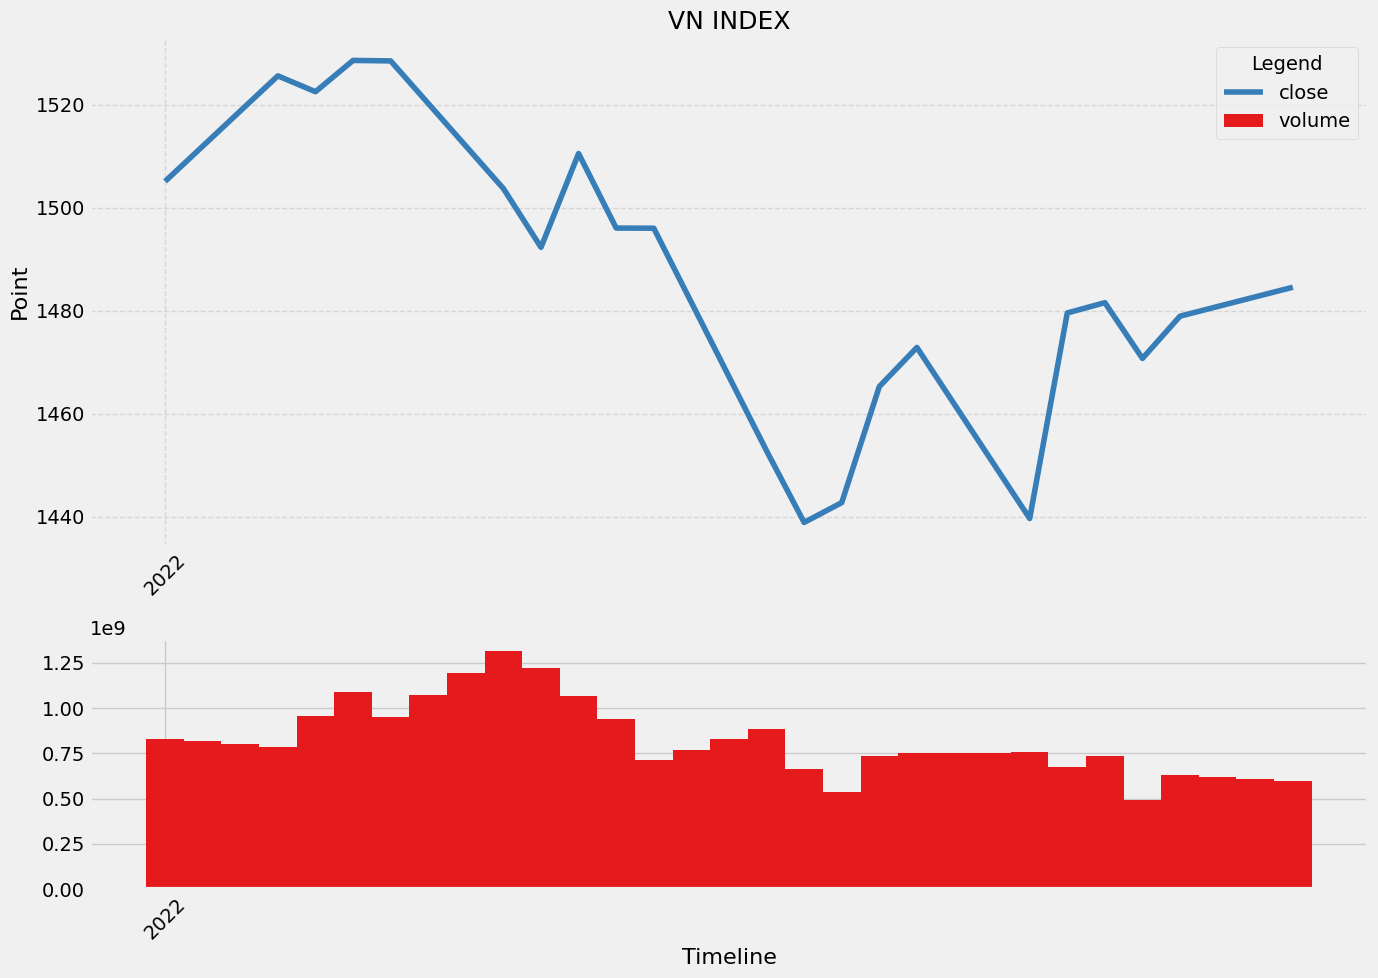

In [302]:
vn_index_plot = my_visualizer.plot_lines_bars_chart(
    vn_index_transform_sub_df,
    x_column="date",
    y_line_columns=["close"],
    y_bar_columns=["volume"],
    title="VN INDEX",
    y_line_axis_title="Point",
    y_bar_axis_title="",
    y_unit="",
    prefix_figure_name="",
    suffix_figure_name=f"{FROM_DATE}_{TO_DATE}",
    marker=None,
    min_date_offset=pd.DateOffset(days=2),
    max_date_offset=pd.DateOffset(days=2),
)
vn_index_plot

### Create model

In [303]:
class LightningLSTM(L.LightningModule):

    def __init__(self):

        super().__init__()

        L.seed_everything(seed=18)

        self.lstm = nn.LSTM(input_size=1, hidden_size=1)

    def forward(self, input):
        # Reshape the input sequence into a column where each row is one time step with one feature
        input_trans = input.view(len(input), 1)

        lstm_out, _ = self.lstm(input_trans)

        prediction = lstm_out[-1]

        return prediction

    def configure_optimizers(
        self,
    ):  # this configures the optimizer we want to use for backpropagation.
        return Adam(
            self.parameters(), lr=0.1
        )  ## we'll just go ahead and set the learning rate to 0.1

    def training_step(self, batch):  # take a step during gradient descent.
        input_i, label_i = batch  # collect input
        output_i = self.forward(input_i[0])  # run input through the neural network
        loss = F.mse_loss(output_i, label_i)

        ###################
        ##
        ## Logging the loss and the predicted values so we can evaluate the training
        ##
        ###################
        self.log("train_loss", loss)

        self.log("label", label_i)
        self.log("prediction", output_i)

        return loss

In [304]:
model = LightningLSTM()

print("Before optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, param.data)

Seed set to 18


Before optimization, the parameters are...
lstm.weight_ih_l0 tensor([[-0.0084],
        [-0.0825],
        [-0.2079],
        [ 0.5043]])
lstm.weight_hh_l0 tensor([[0.8440],
        [0.2090],
        [0.1022],
        [0.0882]])
lstm.bias_ih_l0 tensor([-0.6567, -0.5661, -0.9302,  0.8914])
lstm.bias_hh_l0 tensor([ 0.0441, -0.4316,  0.8025,  0.4003])


In [305]:
print("Before training")
print(f"Observed: {targets[0]}")
print(f"Predicted: {model(inputs[0])}")

Before training
Observed: tensor([0.4763])
Predicted: tensor([-0.0690], grad_fn=<SelectBackward0>)


In [306]:
trainer = L.Trainer(max_epochs=300, log_every_n_steps=1)

trainer.fit(model, train_dataloaders=dataloader)

print("After optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, param.data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm │ LSTM │     16 │ train │     0 │
└───┴──────┴──────┴────────┴───────┴───────┘

Trainable params: 16                                                                                               
Non-trainable params: 0                                                                                            
Total params: 16                                                                                                   
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 1                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9256\2589932311.py:31: UserWarning: Using a target size (torch.Size([1,
1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to 
broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(output_i, label_i)

`Trainer.fit` stopped: `max_epochs=300` reached.


After optimization, the parameters are...
lstm.weight_ih_l0 tensor([[ 0.1736],
        [-0.6653],
        [ 0.9568],
        [ 0.5762]])
lstm.weight_hh_l0 tensor([[ 0.9315],
        [-0.1280],
        [-0.1027],
        [ 0.0475]])
lstm.bias_ih_l0 tensor([-0.4071, -1.1149,  0.2437,  0.9984])
lstm.bias_hh_l0 tensor([ 0.2936, -0.9804,  1.9764,  0.5072])


In [307]:
print("After training")
print(f"Observed: {targets[0]}")
print(f"Predicted: {model(inputs[0])}")

After training
Observed: tensor([0.4763])
Predicted: tensor([0.4763], grad_fn=<SelectBackward0>)
